In [79]:
!pip install pandas numpy matplotlib seaborn scikit-learn shap joblib


In [80]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

import joblib
import shap
import warnings
warnings.filterwarnings("ignore")

In [81]:
# Optional: load real dataset if exists
try:
    df_real = pd.read_csv("lms_churn_dataset.csv")
    print("Loaded existing dataset")
except:
    df_real = None
    print("No existing dataset found")

Loaded existing dataset


In [82]:
np.random.seed(42)
n = 500

df = pd.DataFrame({
    "user_id": np.arange(1, n+1),

    "login_frequency": np.random.randint(1, 30, n),
    "avg_session_time": np.random.randint(5, 120, n),
    "courses_enrolled": np.random.randint(1, 8, n),
    "courses_completed": np.random.randint(0, 10, n),
    "assignments_submitted": np.random.randint(0, 50, n),
    "discussion_posts": np.random.randint(0, 20, n),
    "video_watch_time": np.random.randint(10, 300, n),
    "avg_score": np.random.randint(30, 100, n),
    "last_login_days": np.random.randint(0, 60, n)
})

# Churn rule (behavior-based logic)
df["churn"] = (
    (df["login_frequency"] < 8) &
    (df["avg_session_time"] < 30) &
    (df["avg_score"] < 60) &
    (df["last_login_days"] > 15)
).astype(int)

df.to_csv("lms_churn_dataset.csv", index=False)

df.head()

,user_id,login_frequency,avg_session_time,courses_enrolled,courses_completed,assignments_submitted,discussion_posts,video_watch_time,avg_score,last_login_days,churn
0,1,7,102,2,3,19,4,146,66,2,0
1,2,20,70,2,5,45,3,99,71,46,0
2,3,29,36,2,5,14,17,70,64,23,0
3,4,15,91,6,7,24,18,147,35,26,0
4,5,11,67,7,0,29,3,59,97,39,0


In [83]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   user_id                500 non-null    int64
 1   login_frequency        500 non-null    int32
 2   avg_session_time       500 non-null    int32
 3   courses_enrolled       500 non-null    int32
 4   courses_completed      500 non-null    int32
 5   assignments_submitted  500 non-null    int32
 6   discussion_posts       500 non-null    int32
 7   video_watch_time       500 non-null    int32
 8   avg_score              500 non-null    int32
 9   last_login_days        500 non-null    int32
 10  churn                  500 non-null    int64
dtypes: int32(9), int64(2)
memory usage: 25.5 KB


user_id                  0
login_frequency          0
avg_session_time         0
courses_enrolled         0
courses_completed        0
assignments_submitted    0
discussion_posts         0
video_watch_time         0
avg_score                0
last_login_days          0
churn                    0
dtype: int64

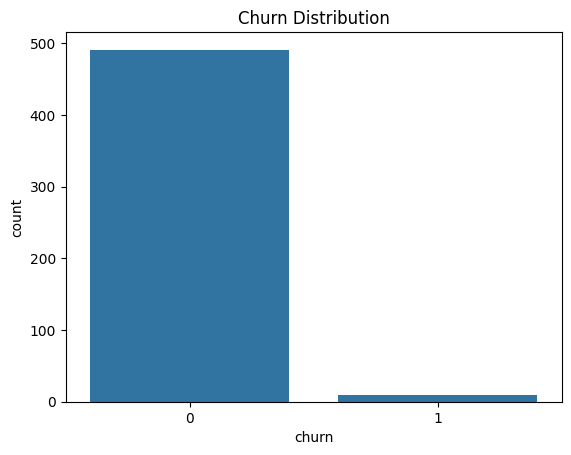

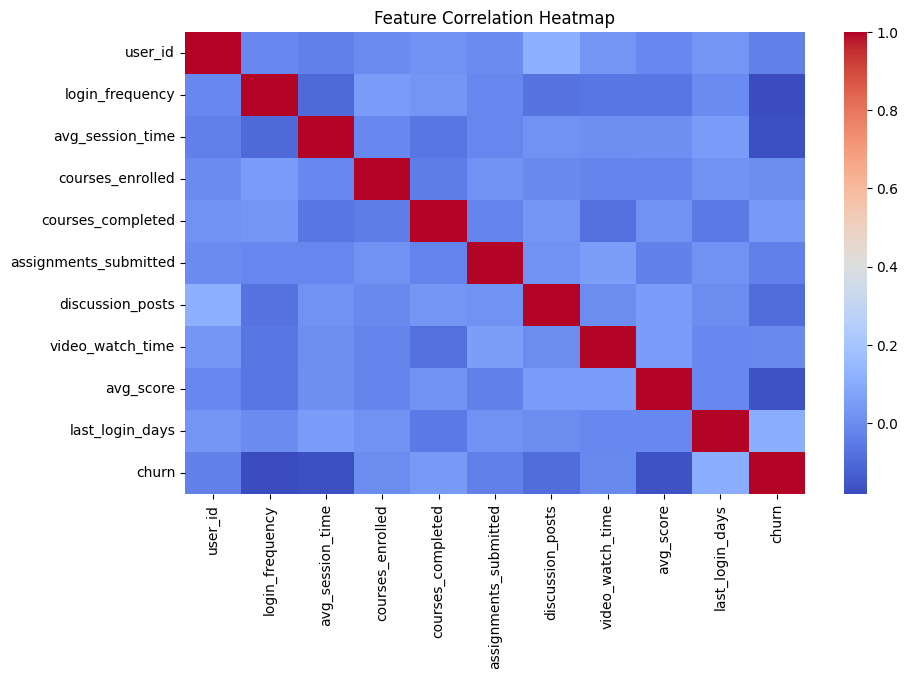

In [84]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [97]:
X = df.drop(columns=["churn", "user_id"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 THIS FIXES IMBALANCE SPLIT
)

In [109]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"  # 🔥 IMPORTANT FIX
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [110]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=1))

Random Forest Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        98
           1       1.00      0.00      0.00         2

    accuracy                           0.98       100
   macro avg       0.99      0.50      0.49       100
weighted avg       0.98      0.98      0.97       100



In [99]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        98
           1       1.00      0.50      0.67         2

    accuracy                           0.99       100
   macro avg       0.99      0.75      0.83       100
weighted avg       0.99      0.99      0.99       100



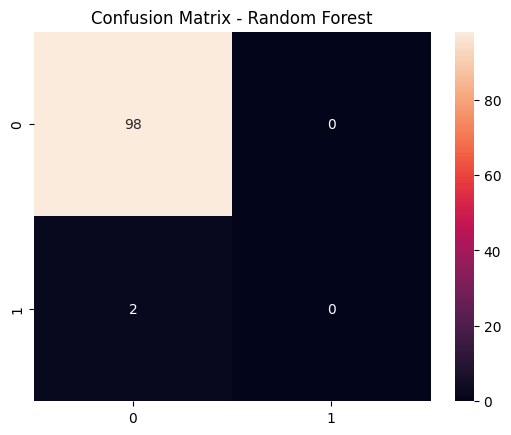

In [100]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

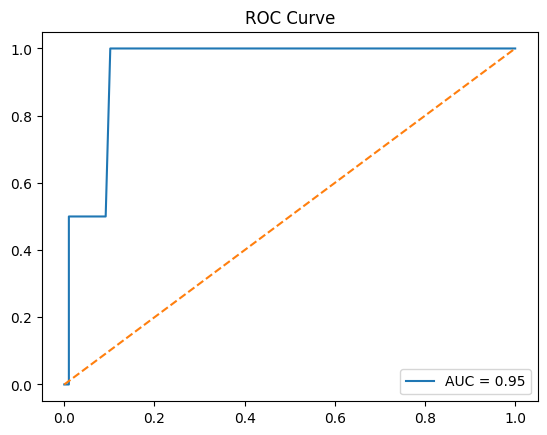

In [101]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')

plt.title("ROC Curve")
plt.legend()
plt.show()

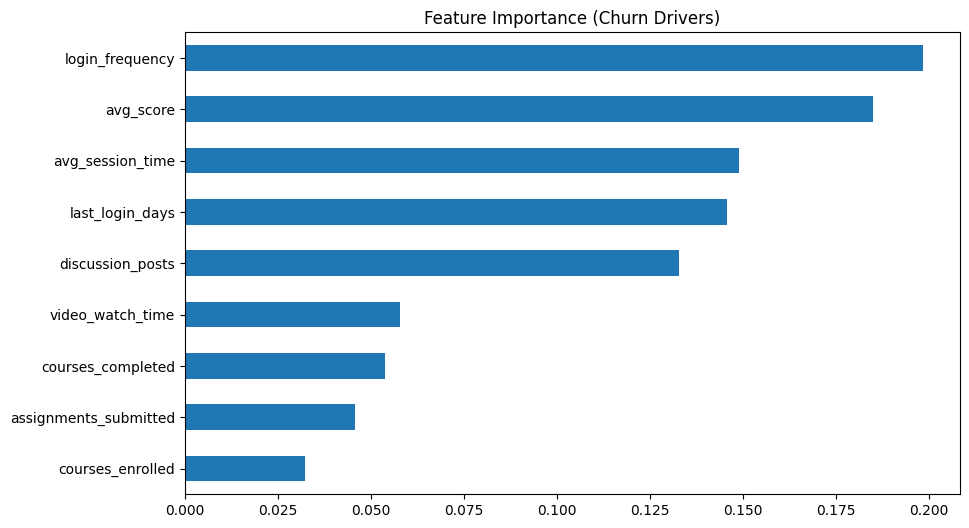

In [102]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance (Churn Drivers)")
plt.show()

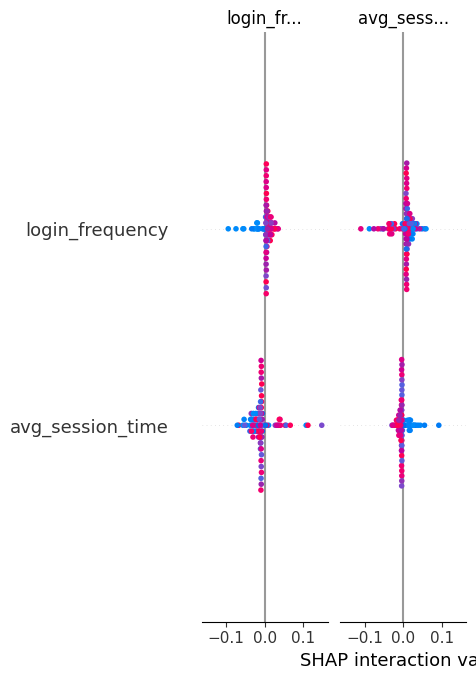

In [103]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_test
)

In [104]:
joblib.dump(rf_model, "churn_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [105]:
churn_rate = df["churn"].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 1.80%


In [111]:
test_results = X_test.copy()
test_results["user_id"] = df.loc[X_test.index, "user_id"].values
test_results["churn_probability"] = rf_model.predict_proba(X_test)[:, 1]

# 🔥 TAKE TOP 10% MOST RISKY USERS (REAL INDUSTRY METHOD)
cutoff = test_results["churn_probability"].quantile(0.90)

likely_churn_users = test_results[
    test_results["churn_probability"] >= cutoff
].sort_values(by="churn_probability", ascending=False)

print("🚨 USERS MOST LIKELY TO CHURN:")
print(likely_churn_users[["user_id", "churn_probability"]])

🚨 USERS MOST LIKELY TO CHURN:
     user_id  churn_probability
170      171               0.23
261      262               0.20
451      452               0.19
499      500               0.15
335      336               0.14
409      410               0.08
270      271               0.07
134      135               0.07
456      457               0.06
192      193               0.05
